In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures", "CSV", "DataFrames", "JSON3", "Dates"
# ]
#     Pkg.add(pkg)
# end

In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates

## Target state

In [4]:
nq = 10
target_beta = 1

target_interaction = 0.346
target_field = 0.822

params_target = parameters(:tfim, nq; field_vals=Dict(:X => -target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_tfim_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta
target_tfim_matrix = paulistringtomatrix(target_tfim_paulis);

In [6]:
targert_circuit, θ = paulistringtocircuit(target_tfim_paulis)

num_layers = 10
max_weight = 10
min_abs_coeff = 1e-10
target_eta = makethermalstate(nq, targert_circuit, θ, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
target_eta_matrix = paulistringtomatrix(target_eta);

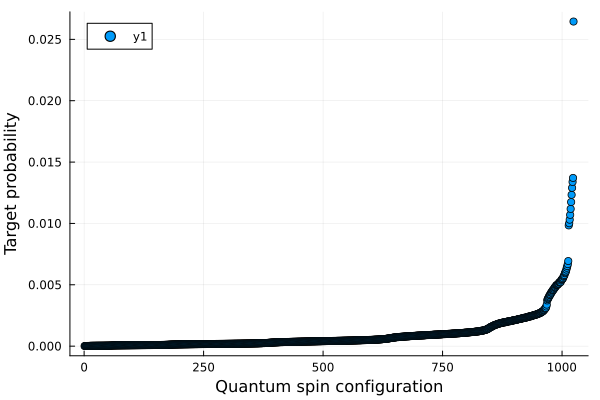

In [7]:
target_probs = computesymmetriceigenvalues(target_eta_matrix);
scatter(target_probs, ylabel="Target probability", xlabel="Quantum spin configuration")

## Model QBM

In [16]:
# parameters to learn. Set initial values at random
rng = MersenneTwister(1)
jz = 0.330
bx = -1.303
@printf("Spin interactions: %f\n", jz)
@printf("Field values: %f\n", bx)

Spin interactions: 0.330000
Field values: -1.303000


In [25]:
beta = 1    
params = parameters(:tfim, nq; field_vals=Dict(:X => bx), coupling_vals=Dict(:ZZ => jz))

qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, theta = paulistringtocircuit(qbm_tfim_paulis)

num_layers_target = 10
max_weight_target = 5
min_abs_coeff_target = 1e-9
qbm = makethermalstate(nq, circuit, theta, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
qbm_matrix = paulistringtomatrix(qbm);

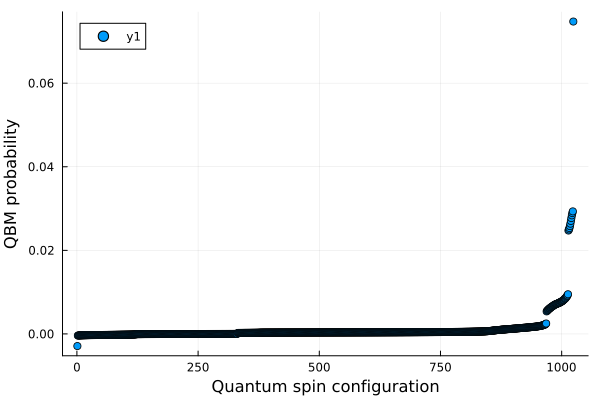

In [19]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(rho_probs, marker=:circle, ylabel="QBM probability", xlabel="Quantum spin configuration")

### Cost function: quantum relative entropy

$$S(\eta \| \rho_\theta) = \operatorname{Tr}[\eta \log \eta]-\operatorname{Tr}\left[\eta \log \rho_\theta\right]$$

In [20]:
computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix)

0.22867422433574802

### Gradient of quantum relative entropy

Given $H_\theta = \sum_i \theta_i H_i$ and the QBM $\rho_\theta = \frac{e^{-\beta H_\theta}}{\operatorname{Tr}[e^{-\beta H_\theta}]}$, the gradient of the cost function (quantum relative entropy) is given by

$$\partial_{\theta_i} S(\eta \| \rho_\theta) = \operatorname{Tr}[H_i \eta] -  \operatorname{Tr}[H_i \rho_\theta]$$

(see Eq. (8) in Tüysüz, Cenk, et al. "Learning to generate high-dimensional distributions with low-dimensional quantum Boltzmann machines." arXiv preprint arXiv:2410.16363 (2024))

In [21]:
grads = computegradients(qbm_tfim_paulis, target_eta, qbm)
println("Gradients: ", grads)

Gradients: [-0.18276608638620578, -0.1827100418981652, -0.1826984012609364, -0.1826871839729602, -0.18267574691061111, -0.182664028765548, -0.18265195938350037, -0.18263945773867946, -0.18262704959296783, -0.18265439768269331, -0.014705833360610966, -0.014689218380827436, -0.014690154273651529, -0.014690978623371001, -0.01469180551885664, -0.014692634875779258, -0.01469346611910511, -0.014694208094060975, -0.0147116752230836]


# Training of the QBM 

In [22]:
# --- Initialization ---
qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta

# learning rate
gamma = 0.2
# number of epochs
epochs = 100
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-3
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    # Build Hamiltonian matrix
    qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

    # Create thermal state
    circuit, theta = paulistringtocircuit(qbm_tfim_paulis)
    num_layers = 10
    max_weight = 5
    min_abs_coeff = 1e-9
    rho = makethermalstate(nq, circuit, theta, num_layers;
                            max_weight=max_weight, min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # --- Gradient computation (efficient) ---
    grads = computegradients(qbm_tfim_paulis, target_eta, rho)
    push!(grad_hist, abs.(grads))

    # --- Parameter update ---
    updatehamiltonian!(qbm_tfim_paulis, grads, gamma)

    # --- Diagnostics ---
    if epoch % 1 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # --- Convergence ---
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 1
  Quantum relative entropy: 0.228674
  Max abs gradient:         0.182766

Epoch 2
  Quantum relative entropy: 0.166060
  Max abs gradient:         0.157803

Epoch 3
  Quantum relative entropy: 0.119644
  Max abs gradient:         0.135398

Epoch 4
  Quantum relative entropy: 0.085630
  Max abs gradient:         0.115557

Epoch 5
  Quantum relative entropy: 0.060944
  Max abs gradient:         0.098188

Epoch 6
  Quantum relative entropy: 0.043173
  Max abs gradient:         0.083120

Epoch 7
  Quantum relative entropy: 0.030466
  Max abs gradient:         0.070142

Epoch 8
  Quantum relative entropy: 0.021431
  Max abs gradient:         0.059036

Epoch 9
  Quantum relative entropy: 0.015036
  Max abs gradient:         0.049581

Epoch 10
  Quantum relative entropy: 0.010527
  Max abs gradient:         0.041565

Epoch 11
  Quantum relative entropy: 0.007358
  Max abs gradient:         0.034798


InterruptException: InterruptException:

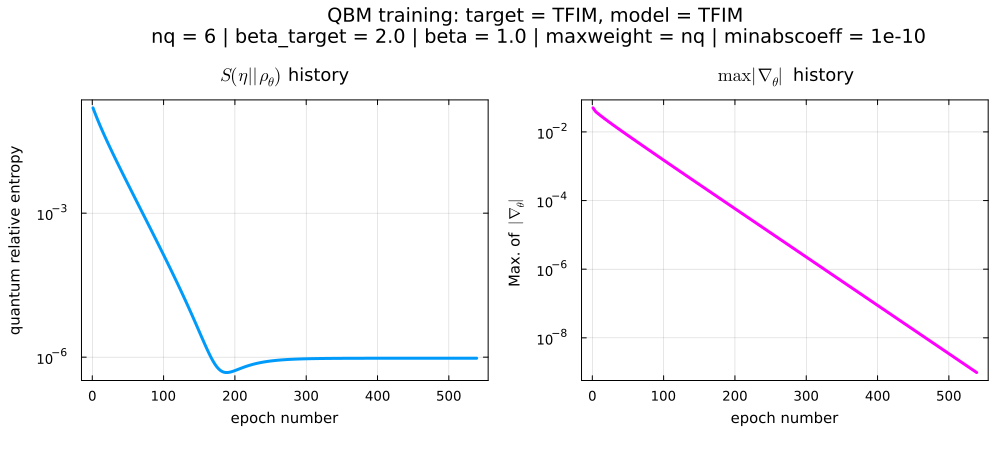

In [17]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = TFIM, model = TFIM\n nq = 6 | beta_target = 2.0 | beta = 1.0 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

## Compare the final parameters with the target parameters.

**Note** the Hamiltonian is the same but the target state was created with $\beta = 2 $ and we use a QBM with $\beta = 1$.

In [18]:
@printf("Original target hamiltonian:")
target_tfim_paulis

Original target hamiltonian:

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.822 * XIIIII)
 PauliString(nqubits: 6, -0.822 * IXIIII)
 PauliString(nqubits: 6, -0.822 * IIXIII)
 PauliString(nqubits: 6, -0.822 * IIIXII)
 PauliString(nqubits: 6, -0.822 * IIIIXI)
 PauliString(nqubits: 6, -0.822 * IIIIIX)
 PauliString(nqubits: 6, 0.173 * ZZIIII)
 PauliString(nqubits: 6, 0.173 * IZZIII)
 PauliString(nqubits: 6, 0.173 * IIZZII)
 PauliString(nqubits: 6, 0.173 * IIIZZI)
 PauliString(nqubits: 6, 0.173 * IIIIZZ)

In [19]:
@printf("Learnt hamiltonian:")
qbm_tfim_paulis

Learnt hamiltonian:

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.822 * XIIIII)
 PauliString(nqubits: 6, -0.822 * IXIIII)
 PauliString(nqubits: 6, -0.822 * IIXIII)
 PauliString(nqubits: 6, -0.822 * IIIXII)
 PauliString(nqubits: 6, -0.822 * IIIIXI)
 PauliString(nqubits: 6, -0.822 * IIIIIX)
 PauliString(nqubits: 6, 0.173 * ZZIIII)
 PauliString(nqubits: 6, 0.173 * IZZIII)
 PauliString(nqubits: 6, 0.173 * IIZZII)
 PauliString(nqubits: 6, 0.173 * IIIZZI)
 PauliString(nqubits: 6, 0.173 * IIIIZZ)

Compare the "images" of the target and trained QBM density matrices

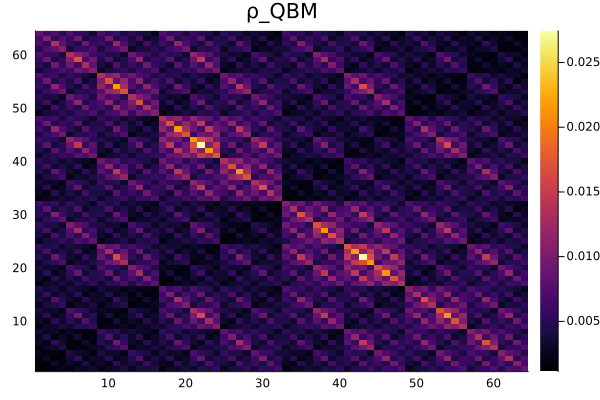

In [20]:
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, angles = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
max_weight = nq
min_abs_coeff = 1e-10
qbm = makethermalstate(nq, circuit, angles, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

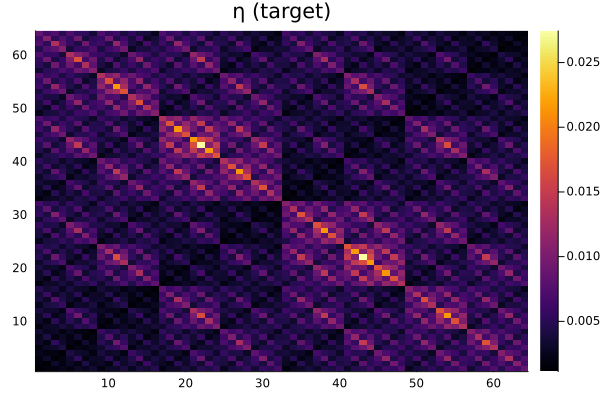

In [21]:
heatmap(reverse(real(target_eta_matrix); dims=1), title="η (target)")

A way to compare the two density matrices is to compute the fidelity between them. A fidelity close to 1 means the two quantum states are the same

In [22]:
# Uhlmann fidelity (squared) between density matrices
function fidelity(ρ::AbstractMatrix, σ::AbstractMatrix)
    F = 0.0
    # sqrt(ρ)
    evals, evecs = eigen(Hermitian(ρ))
    sqrtρ = evecs * Diagonal(sqrt.(clamp.(evals, 0, Inf))) * evecs'
    A = sqrtρ * σ * sqrtρ
    evalsA = computesymmetriceigenvalues(A)
    rootF = sum(sqrt.(clamp.(evalsA, 0, Inf)))
    (rootF)^2
end

fidelity (generic function with 1 method)

In [23]:
# fidelity
F = fidelity(target_eta_matrix, qbm_matrix)
F

1.000000000000031

We can also plot the probability distributions:

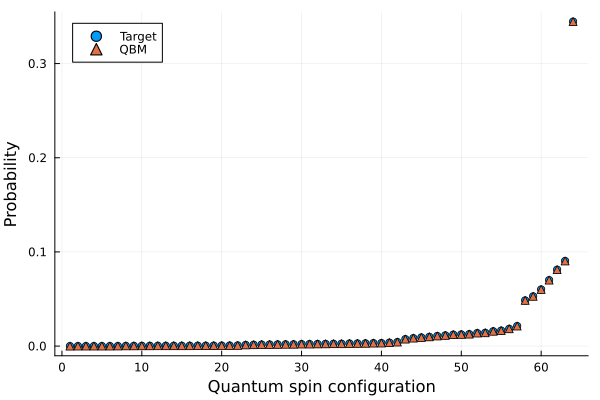

In [24]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(1:length(rho_probs), target_probs, label="Target", marker=:circle, xlabel="Quantum spin configuration", ylabel="Probability")
scatter!(1:length(rho_probs), rho_probs, label="QBM", marker=:utriangle)

### Different temperatures


Starting optimization for β = 0.100
  [β=0.10 | epoch=   1]  QRE = 5.652929e-01   max|∇| = 3.234941e-01
  [β=0.10 | epoch=   2]  QRE = 3.698230e-01   max|∇| = 2.594457e-01
  [β=0.10 | epoch=   3]  QRE = 2.438518e-01   max|∇| = 2.088461e-01
  [β=0.10 | epoch=   4]  QRE = 1.620117e-01   max|∇| = 1.688063e-01
  [β=0.10 | epoch=   5]  QRE = 1.083783e-01   max|∇| = 1.369891e-01
  [β=0.10 | epoch=   6]  QRE = 7.293632e-02   max|∇| = 1.115752e-01
  [β=0.10 | epoch=   7]  QRE = 4.933815e-02   max|∇| = 9.116908e-02
  [β=0.10 | epoch=   8]  QRE = 3.352143e-02   max|∇| = 7.473563e-02
  [β=0.10 | epoch=   9]  QRE = 2.285941e-02   max|∇| = 6.143227e-02
  [β=0.10 | epoch=  10]  QRE = 1.563696e-02   max|∇| = 5.060291e-02
  [β=0.10 | epoch=  11]  QRE = 1.072416e-02   max|∇| = 4.175667e-02
  [β=0.10 | epoch=  12]  QRE = 7.370724e-03   max|∇| = 3.450871e-02
  [β=0.10 | epoch=  13]  QRE = 5.074965e-03   max|∇| = 2.855507e-02
  [β=0.10 | epoch=  14]  QRE = 3.499433e-03   max|∇| = 2.365397e-02
  [β=0.10 |

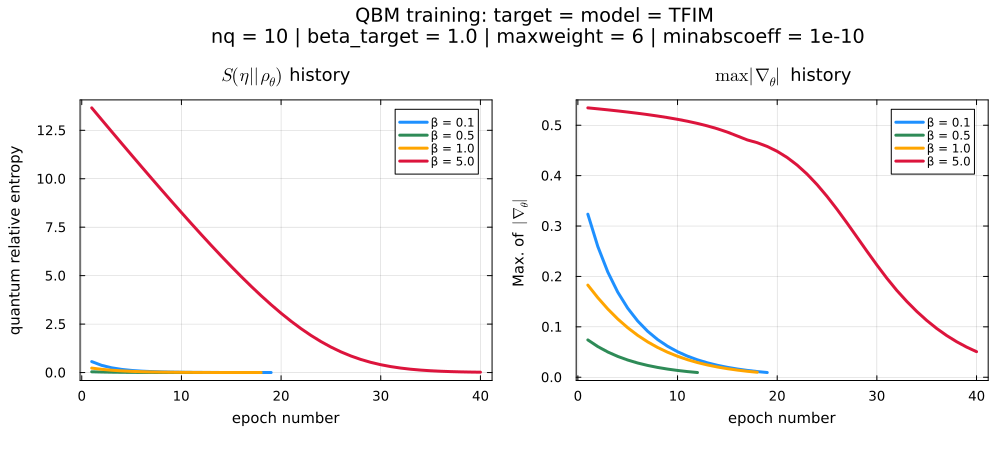

In [26]:
# beta values 
beta_values = [0.1, 0.5, 1, 5]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 40
# stop when gradient is smaller than epsilon
epsilon = 1e-2

# Output path
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetTFIM_qbmTFIM_10qb"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    # yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    # yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over β values
for (i, beta) in enumerate(beta_values)

    println("\n" * "="^60)
    @printf("Starting optimization for β = %.3f\n", beta)
    println("="^60)

    # QBM model
    jz = 0.330
    bx = -1.303
    params = parameters(:tfim, nq; field_vals=Dict(:X => bx), coupling_vals=Dict(:ZZ => jz))   
    
    qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
    ## truncation parameters
    num_layers_qbm = 10
    max_weight_qbm = 5
    min_abs_coeff_qbm = 1e-9

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_tfim_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_tfim_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_tfim_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 1 == 0
            @printf("  [β=%.2f | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    beta, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this β
    @printf("\nFinished β = %.3f  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            beta, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # ------------------------- #
    # --- SAVE DATA TO FILE --- #
    # ------------------------- #

    # Save optimization histories as CSV
    df = DataFrame(epoch = 1:length(qre_hist),
                   qre = qre_hist,
                   max_grad = [maximum(g) for g in grad_hist])
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    CSV.write(csv_path, df)
    @printf("  → Saved CSV data to %s\n", csv_path)

    # Collect metadata only once per run
    metadata = Dict(
        "timestamp" => string(now()),
        "model_target" => "TFIM",
        "model_qbm" => "TFIM",
        "n_qubits" => nq,
        "beta_target" => target_beta,
        "beta_qbm" => beta,
        "beta_values" => beta_values,
        "learning_rate" => gamma,
        "epochs" => epochs,
        "epsilon" => epsilon,
        "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
                                "wij_xyz" => params_target.wij_xyz),
        "target_truncation" => Dict("max_weight" => max_weight_target,
                                    "min_abs_coeff" => min_abs_coeff_target,
                                    "num_layers" => num_layers_target),
        "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
                                 "min_abs_coeff" => min_abs_coeff_qbm,
                                 "num_layers" => num_layers_qbm)
    )

    json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    JSON3.write(json_path, metadata; indent=2)
    @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "β = $(beta)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "β = $(beta)", color = colors[i], lw = 3)
end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = model = TFIM\n nq = 10 | beta_target = 1.0 | maxweight = 6 | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

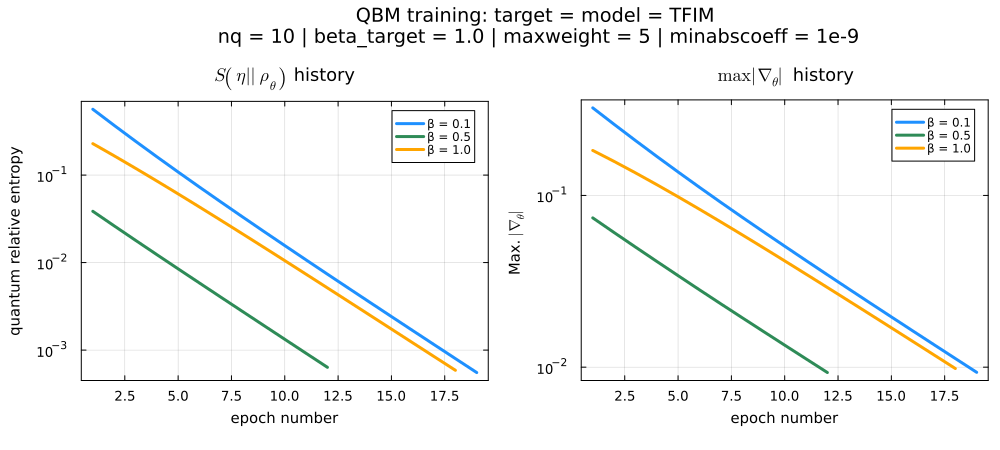

In [ ]:
# --- Settings ---
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetTFIM_qbmTFIM_10qb"
beta_values = [0.1, 0.5, 1]                # plot only these
colors = [:dodgerblue, :seagreen, :orange] # same as before

# --- Prepare plots ---
p1 = plot(
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\eta || \rho_\theta\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
)

# --- Load and plot each β file ---
for (i, beta) in enumerate(beta_values)
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    if isfile(csv_path)
        df = CSV.read(csv_path, DataFrame)
        plot!(p1, df.epoch, df.qre;
              label = "β = $(beta)",
              color = colors[i],
              lw = 3)
        plot!(p2, df.epoch, df.max_grad;
              label = "β = $(beta)",
              color = colors[i],
              lw = 3)
    else
        @warn "File not found: $csv_path"
    end
end

# --- Combine and display ---
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = model = TFIM\n nq = 10 | beta_target = 1.0 | maxweight = 5 | minabscoeff = 1e-9",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


# Target XXX Heisenberg, Model XYZ Heisenberg

In [4]:
n = 12
target_interactions = (1.0, 1.0, 1.0)
target_interactions = 4 .* target_interactions
params_target = parameters(:heisenberg, n; coupling_vals=Dict(:XX => target_interactions[1], :YY => target_interactions[2], :ZZ => target_interactions[3]))

target_xxx = makehamiltonian(params_target; connectivity=:nearest, periodic=true)
target_xxx_matrix = paulistringtomatrix(target_xxx);

In [5]:
num_layers = 10
max_weight = 5
min_abs_coeff = 1e-10

target_beta1 = 1

target_xxx_beta1 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta1
target_xxx_matrix_beta1 = paulistringtomatrix(target_xxx_beta1)
targert_circuit_beta1, θ_beta1 = paulistringtocircuit(target_xxx_beta1)

target_eta_beta1 = makethermalstate(n, targert_circuit_beta1, θ_beta1, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta1_matrix = paulistringtomatrix(target_eta_beta1);

In [6]:
target_probs_beta1 = computesymmetriceigenvalues(target_eta_beta1_matrix)
target_probs_beta1 = clamp.(target_probs_beta1, 1e-300, Inf);

In [ ]:
# beta values 
beta_values = [0.1, 0.5, 1, 2]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 30
# stop when gradient is smaller than epsilon
epsilon = 1e-2

# Output path
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetXXX_qbmXYZ_12qb"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    # yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    # yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over β values
for (i, beta) in enumerate(beta_values)

    println("\n" * "="^60)
    @printf("Starting optimization for β = %.3f\n", beta)
    println("="^60)

    # QBM model
    rng = MersenneTwister(1)  
    interactions = Tuple(randn(rng, 3))   
    params = parameters(:heisenberg, n; coupling_vals=Dict(:XX => interactions[1], :YY => interactions[2], :ZZ => interactions[3])) 
    qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true) * beta

    ## truncation parameters
    num_layers_qbm = 10
    max_weight_qbm = 4
    min_abs_coeff_qbm = 1e-8

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
        push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1, qbm_xyz_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_xyz)
        rho = makethermalstate(n, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_xyz, target_eta_beta1, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_xyz, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 1 == 0
            @printf("  [β=%.2f | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    beta, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this β
    @printf("\nFinished β = %.3f  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            beta, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # ------------------------- #
    # --- SAVE DATA TO FILE --- #
    # ------------------------- #

    # Save optimization histories as CSV
    df = DataFrame(epoch = 1:length(qre_hist),
                   qre = qre_hist,
                   max_grad = [maximum(g) for g in grad_hist])
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    CSV.write(csv_path, df)
    @printf("  → Saved CSV data to %s\n", csv_path)

    # Collect metadata only once per run
    metadata = Dict(
        "timestamp" => string(now()),
        "model_target" => "XXX",
        "model_qbm" => "XYZ",
        "n_qubits" => n,
        "beta_target" => target_beta1,
        "beta_qbm" => beta,
        "beta_values" => beta_values,
        "learning_rate" => gamma,
        "epochs" => epochs,
        "epsilon" => epsilon,
        "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
                                "wij_xyz" => params_target.wij_xyz),
        "target_truncation" => Dict("max_weight" => max_weight,
                                    "min_abs_coeff" => min_abs_coeff,
                                    "num_layers" => num_layers),
        "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
                                 "min_abs_coeff" => min_abs_coeff_qbm,
                                 "num_layers" => num_layers_qbm)
    )

    json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    JSON3.write(json_path, metadata; indent=2)
    @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "β = $(beta)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "β = $(beta)", color = colors[i], lw = 3)
end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = XXX | model = XYZ\n nq = 12 | beta_target = 1 | maxweight = 4 | minabscoeff = 1e-8",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for β = 0.100
  [β=0.10 | epoch=   1]  QRE = 1.412014e+00   max|∇| = 4.493961e-01
  [β=0.10 | epoch=   2]  QRE = 5.308024e-01   max|∇| = 3.516125e-01
  [β=0.10 | epoch=   3]  QRE = -9.960245e-03   max|∇| = 2.705413e-01
  [β=0.10 | epoch=   4]  QRE = -3.345127e-01   max|∇| = 2.103651e-01
  [β=0.10 | epoch=   5]  QRE = -5.324111e-01   max|∇| = 1.676935e-01


# Target XXX Heisenberg, Model XYZ Heisenberg

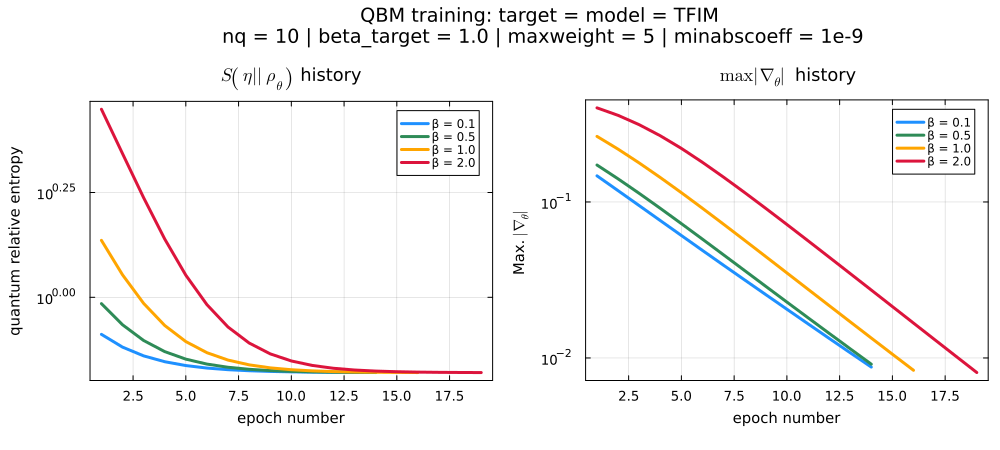

In [7]:
# --- Settings ---
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetXXX_qbmXYZ_10qb"
beta_values = [0.1, 0.5, 1, 2]                # plot only these
colors = [:dodgerblue, :seagreen, :orange, :crimson] # same as before

# --- Prepare plots ---
p1 = plot(
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\eta || \rho_\theta\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
)

# --- Load and plot each β file ---
for (i, beta) in enumerate(beta_values)
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    if isfile(csv_path)
        df = CSV.read(csv_path, DataFrame)
        plot!(p1, df.epoch, df.qre;
              label = "β = $(beta)",
              color = colors[i],
              lw = 3)
        plot!(p2, df.epoch, df.max_grad;
              label = "β = $(beta)",
              color = colors[i],
              lw = 3)
    else
        @warn "File not found: $csv_path"
    end
end

# --- Combine and display ---
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = model = TFIM\n nq = 10 | beta_target = 1.0 | maxweight = 5 | minabscoeff = 1e-9",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


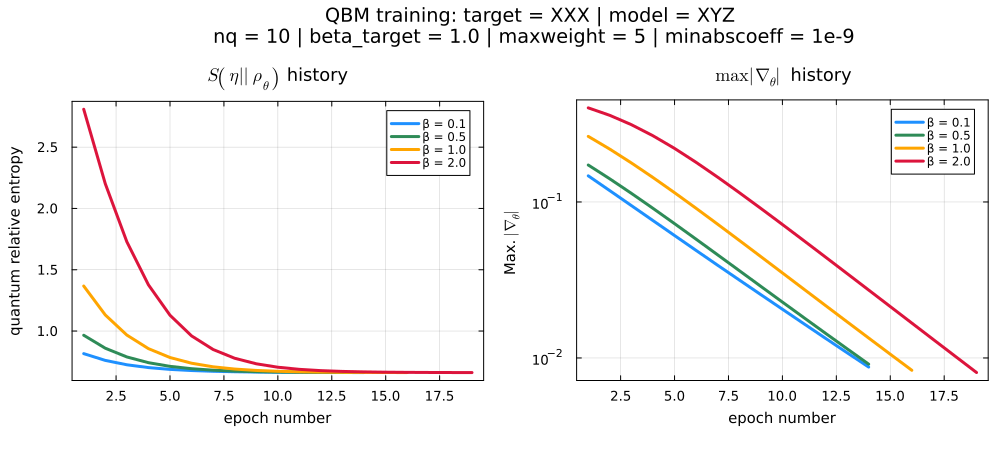

In [3]:
# --- Settings ---
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetXXX_qbmXYZ_10qb"
beta_values = [0.1, 0.5, 1, 2]                # plot only these
colors = [:dodgerblue, :seagreen, :orange, :crimson] # same as before

# --- Prepare plots ---
p1 = plot(
    # yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\eta || \rho_\theta\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
)

# --- Load and plot each β file ---
for (i, beta) in enumerate(beta_values)
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    if isfile(csv_path)
        df = CSV.read(csv_path, DataFrame)
        plot!(p1, df.epoch, df.qre;
              label = "β = $(beta)",
              color = colors[i],
              lw = 3)
        plot!(p2, df.epoch, df.max_grad;
              label = "β = $(beta)",
              color = colors[i],
              lw = 3)
    else
        @warn "File not found: $csv_path"
    end
end

# --- Combine and display ---
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = XXX | model = XYZ\n nq = 10 | beta_target = 1.0 | maxweight = 5 | minabscoeff = 1e-9",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)
